# Exploratory Analysis on Penguin on Palmer Archipelago

## Objective

The task is to explore and analyze the relationship between penguins' habitats, sex, and species and penguins body measurements, including body mass, culmen length and depth, and flipper length. 

## Basic Info

The dataset `Penguins.csv` contains 334 samples collected from 3 islands in Palmer Archipelago. 

The meaning of each column in the dataset:
- species: Penguin species
- island: Penguins' habitat
- culmen_length_mm: length of penguins' culmens (unit: mm)
- culmen_depth_m:：depth of penguins' culmens (unit: mm)
- flipper_length_mm: length of penguins' flippers (unit: mm)
- body_mass_g: penguins' body weight (unit: g)
- sex：penguins' sex

#### Read the Dataset

Import the packages needed, and read the .csv file. 
Transform the original dataset into a DataFrame `original_data`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
original_data = pd.read_csv('Penguins.csv')
original_data.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


### Evaluate and Clean the Dataset

In this section, an evaluation and cleaning process for `original_data` will be done.

I will conduct two main approaches: 
- Structure (Tidy)
- Content (Clean)

In order to distinguish the processed version and the original version, I will create a new DataFrame, `cleaned_data`, by making a copy of `original_data`. The later steps will be done on`cleaned_data`.

In [3]:
cleaned_data = original_data.copy()

#### The Extent of Tidiness

In [5]:
cleaned_data.head(10)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,FEMALE
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,MALE
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


From the top 10 lines, this dataset satisfy the basic tidiness for a dataset that is ready to analyze. Hence, no structural problem is detected.

#### The Extent of Clean

Scan the data with `info`.

In [6]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


There are 344 observations in `cleaned_data`. 

There are null values in `culmen_length_mm`, `culmen_depth_mm`, `flipper_length_mm`, and `body_mass_g`.

Data type wise, `species`, `sex` and `island` are categorical data, so their data type should be transformed to `Category`.

In [7]:
cleaned_data['species'] = cleaned_data['species'].astype('category')
cleaned_data['sex'] = cleaned_data['sex'].astype('category')
cleaned_data['island'] = cleaned_data['island'].astype('category')

In [8]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   species            344 non-null    category
 1   island             344 non-null    category
 2   culmen_length_mm   342 non-null    float64 
 3   culmen_depth_mm    342 non-null    float64 
 4   flipper_length_mm  342 non-null    float64 
 5   body_mass_g        342 non-null    float64 
 6   sex                334 non-null    category
dtypes: category(3), float64(4)
memory usage: 12.3 KB


#### Missing Values

As shown in previous results, there are missing values in `culmen_length_mm`, `culmen_depth_mm`, `flipper_length_mm`, `body_mass_g`, and `sex`.

Extract the observations with missing values.

In [9]:
cleaned_data.query('culmen_length_mm.isna()')

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


In [10]:
cleaned_data.query('culmen_depth_mm.isna()')

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


In [11]:
cleaned_data.query('flipper_length_mm.isna()')

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


In [13]:
cleaned_data.query('body_mass_g.isna()')

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


In observation 3 and 339, all the variables are null except island. Hence, these two observations can bring no contribution to following analysis. 

They will be deleted.

In [14]:
cleaned_data.drop(3, inplace = True)
cleaned_data.drop(339, inplace = True)

In [15]:
cleaned_data.query('sex.isna()')

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN


The observations that miss `sex` variable still contain other data, hence they are valid for later analysis.

Pandas, Matplotlib and Seaborn can ignore null value automatically. Therefore, these observations can be kept.

#### Duplicate Value

According to the variable meanings and content, duplicate values are allowed. 

#### Inconsistant Value

Data inconsistancy is possible under every categorical variables.

In [16]:
cleaned_data['species'].value_counts()

species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64

In [17]:
cleaned_data['island'].value_counts()

island
Biscoe       167
Dream        124
Torgersen     51
Name: count, dtype: int64

In [18]:
cleaned_data['sex'].value_counts()

sex
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64

According to the results, variables `species` and `island` do not show any inconsistant data. 

Under variable `sex`, there is one value `.`, which has no meaning. It will be substituted by `NaN`.

In [20]:
cleaned_data['sex'] = cleaned_data['sex'].replace('.', np.nan)
cleaned_data['sex'].value_counts()

sex
MALE      168
FEMALE    165
Name: count, dtype: int64

As shown above, the `.` is replaced by a `NaN` value.

#### Invalid and Wrong Data

Scan the dataset with `describe`.

In [21]:
cleaned_data.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


According to the result above, `cleaned_data` does not contain invalid data.

### Explore the data

In [23]:
sns.set_palette('pastel')

In [24]:
cleaned_data

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


#### Proportion of Species

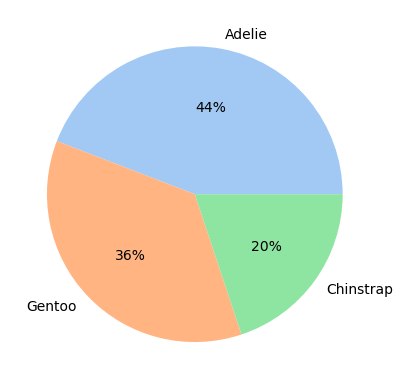

In [26]:
species_count = cleaned_data['species'].value_counts()
plt.pie(species_count, autopct = '%.0f%%', labels = species_count.index)
plt.show()

As shown on the graph above, `Adelie` takes the highest proportion, following by `Gentoo`. `Chinstrap` is the least, about 1/5.

#### Proportion of Islands

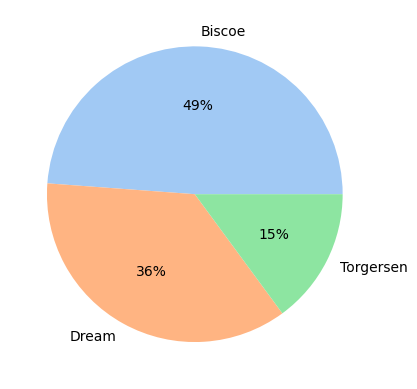

In [28]:
islands_count = cleaned_data['island'].value_counts()
plt.pie(islands_count, autopct = '%.0f%%', labels = islands_count.index)
plt.show()

About half of penguin samples are from island `Biscoe`, following by `Dream`. `Torgersen` takes up the least percentage.

#### Proportion of Penguin Sex

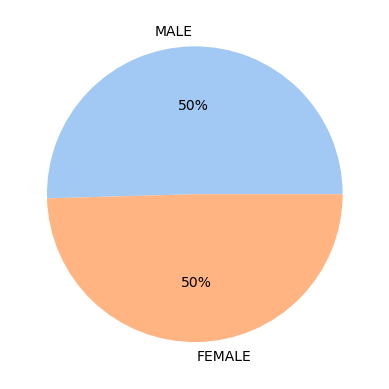

In [29]:
sex_count = cleaned_data['sex'].value_counts()
plt.pie(sex_count, labels=sex_count.index, autopct='%.0f%%')
plt.show()

Half `MALE` and half `FEMALE`, which means the sample collected is perfectly random.

#### Number of Different Species on Each Island

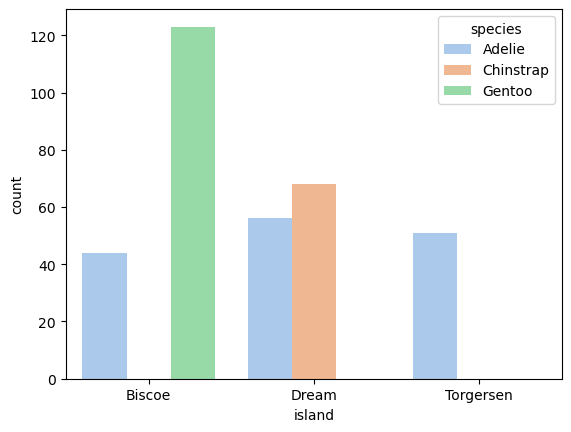

In [31]:
sns.countplot(cleaned_data, x = 'island', hue = 'species')
plt.show()

From the results above, `Adelie` shows up on all three islands, while `Chinstrap` only appears on island `Dream`, and `Gentoo` only appears on `Biscoe`.

#### Sex Distribution on Different Islands

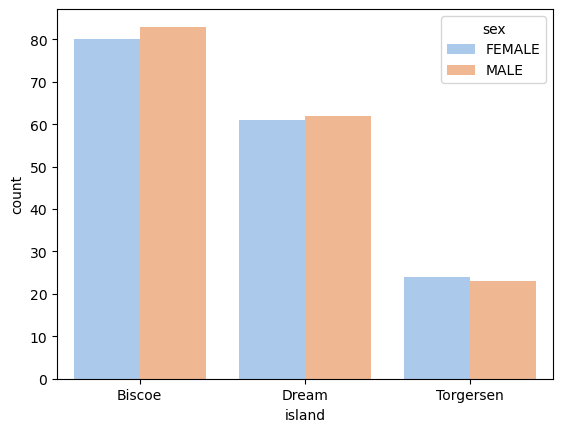

In [32]:
sns.countplot(cleaned_data, x = 'island', hue = 'sex')
plt.show()

#### The Relation between Every Two Variabels

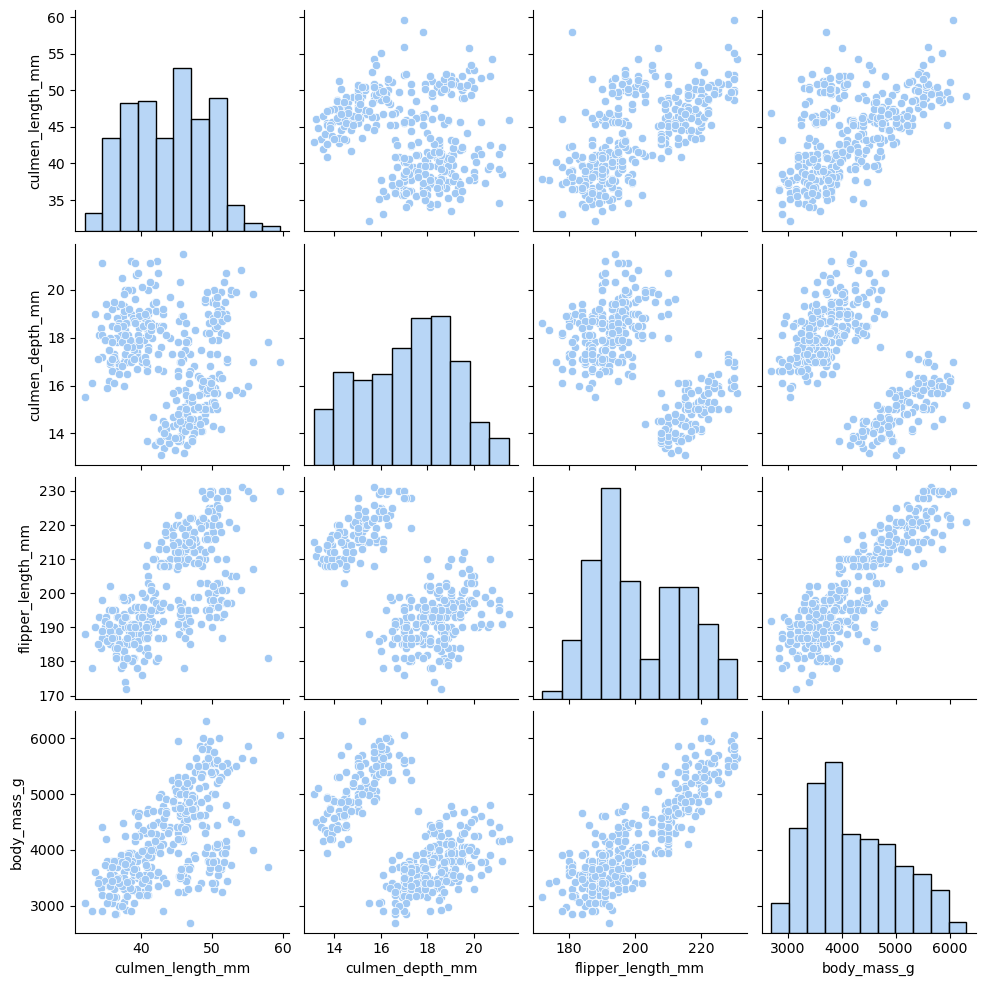

In [33]:
sns.pairplot(cleaned_data)
plt.show()

According to the histograms, we can see that the culmen length, culmen depth, flipper length, and body mass are not normally distributed. This could means either:
- There are numerous samples that shows difference, or
- The sample size is not big enough.

What's more, there are some obvious clusters among the scatter plots. It could be related to some certain variabels, such as species and sex, which could be further analyzed.

#### Relations According to Species

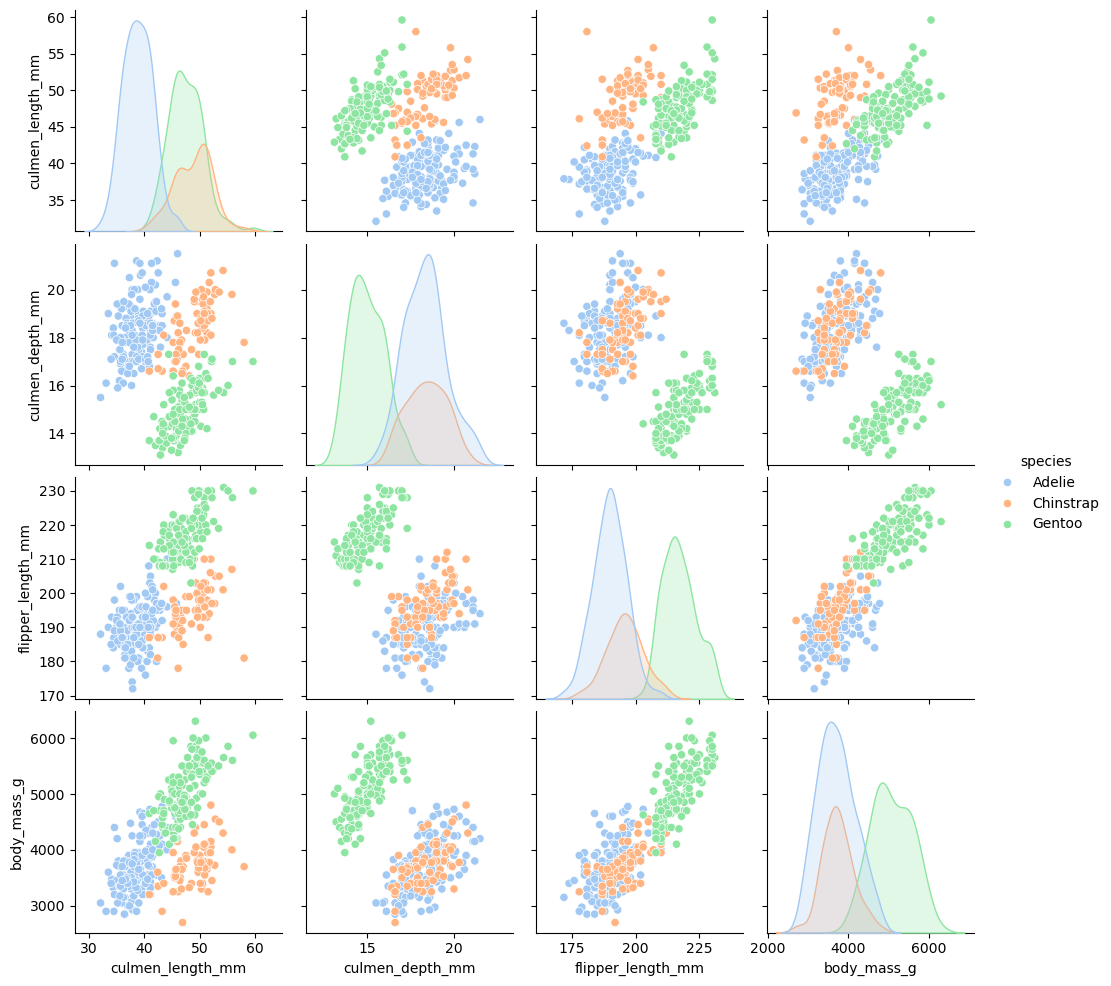

In [34]:
sns.pairplot(cleaned_data, hue = 'species')
plt.show()

In the scatter plots, observation points of the same species are grouped together, which means the culmen, flipper and body mass data are similar among penguins from the same specie.

Therefore, we can infer the the specie of a penguin with the measurement of its culmen, flipper and body mass, and vice versa.

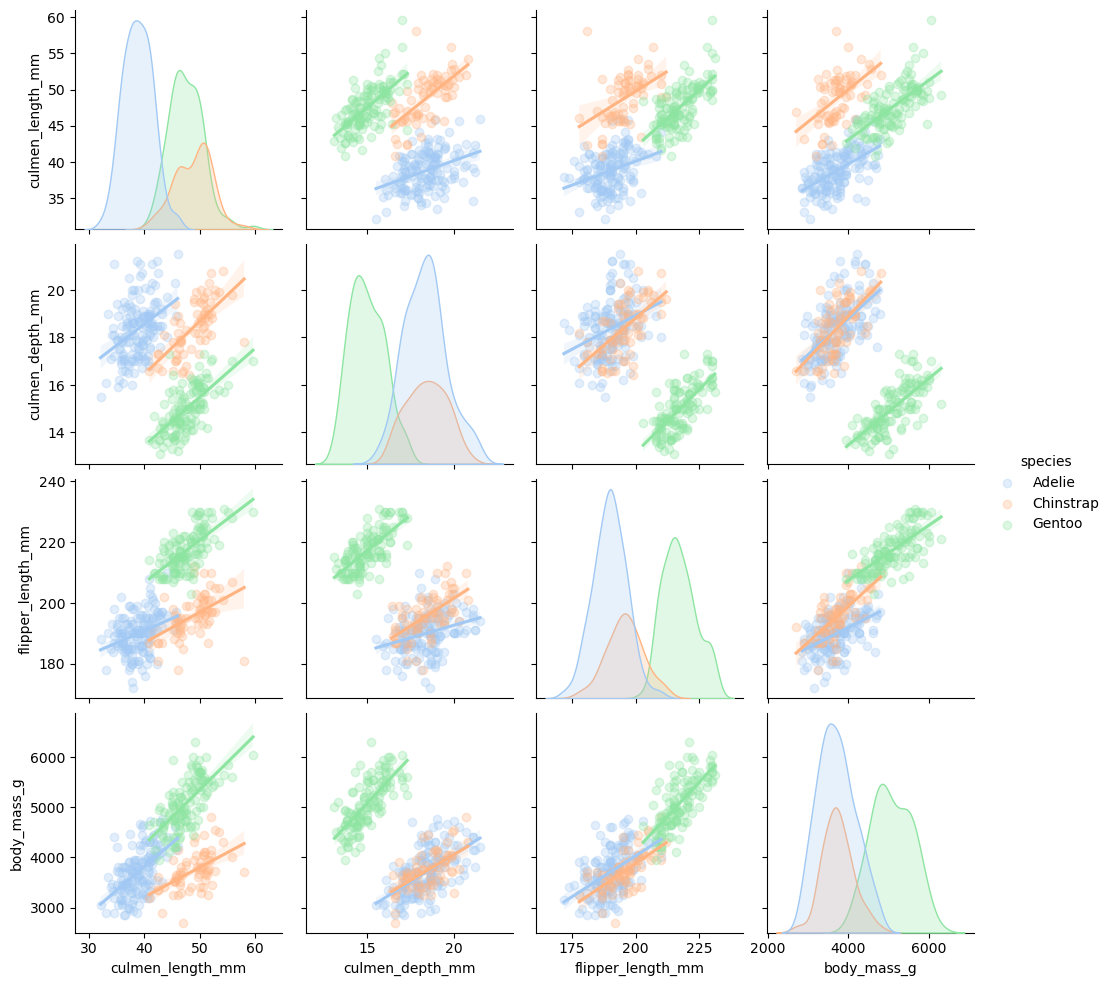

In [36]:
sns.pairplot(cleaned_data, hue = 'species', kind = 'reg', plot_kws = {'scatter_kws': {'alpha': 0.3}})
plt.show()

After combining scatter plots and linear regression, we can see that the measurements among the same species are preforming a positive relationship between each other. i.e. the longer the culmen, the deeper the culmen; the longer the flipper, the heavier the body mass.

From the distribution map, we can see the following:
- Chinstrap and Gentoo has similar range in culmen length, while Adelie has a shorter culmen.
- Adelie and Chinstrap has similar culmen depth, while Gentoo has a shallower culmen.
- Adelie's flipper is the shortest, following by Chinstrap, and then Gentoo.
- Adelie and Chinstrap has similar range on body mass, while Gentoo has a heavier body mass.

However, further research is needed to see if data from different species shows statistically significant difference. 

#### Relations According to Sexes

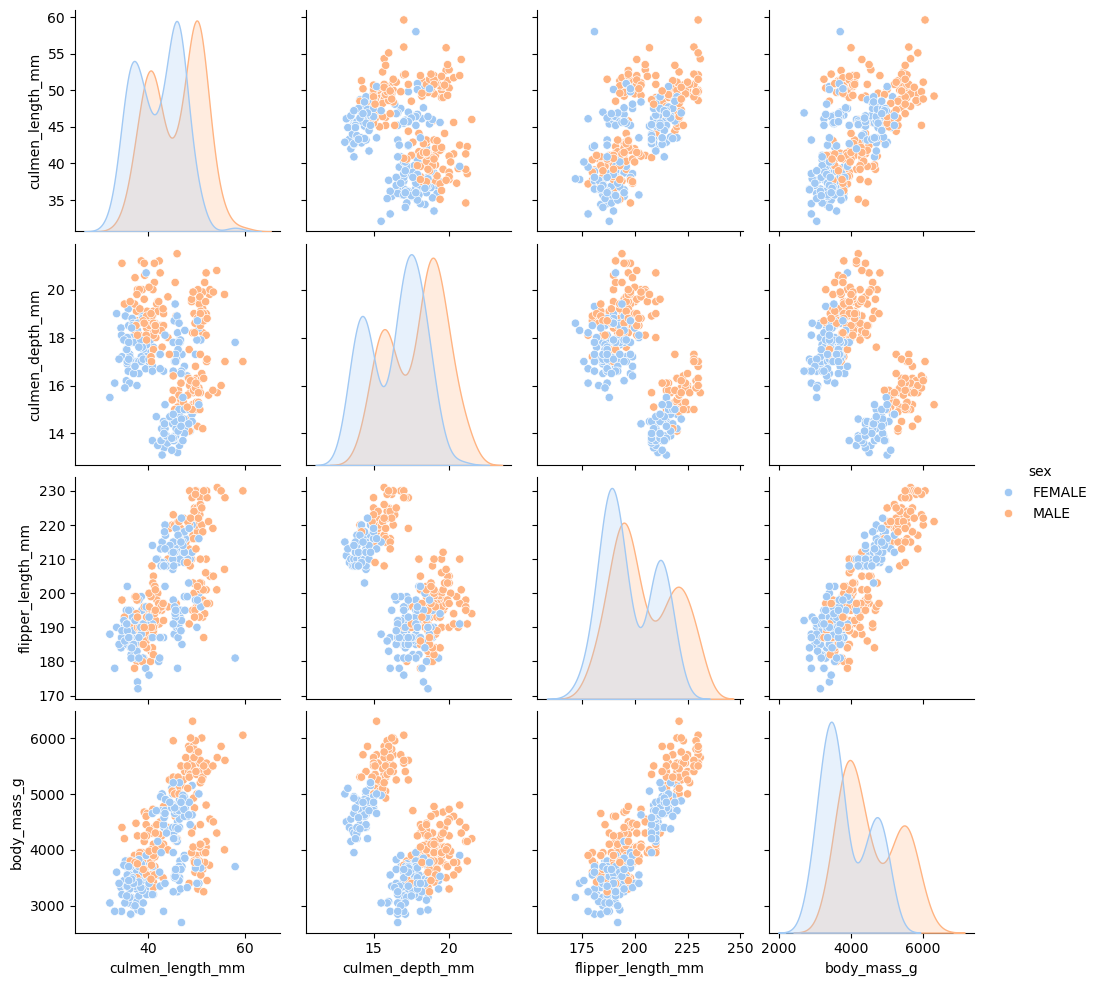

In [38]:
sns.pairplot(cleaned_data, hue = 'sex')
plt.show()

After we split the observations with their sex, we can see that male penguins are higher than female ones in each body measurements. 